In [267]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn import tree
from sklearn import svm
from sklearn.metrics import mean_squared_error, r2_score

# Clusters

In [268]:
ruta = './Data/'
clientes = pd.read_excel(f'{ruta}Clientes.xlsx')
Detalle_ventas = pd.read_excel(f'{ruta}Detalle_ventas.xlsx')
Productos = pd.read_excel(f'{ruta}Productos.xlsx')
Ventas = pd.read_excel(f'{ruta}Ventas.xlsx')

In [269]:
df_cluster = (
    Ventas[['id_cliente', 'medio_pago', 'id_venta']]
    .merge(Detalle_ventas[['id_venta', 'cantidad', 'importe']], on = 'id_venta')
)

In [270]:
enc = OrdinalEncoder()
df_cluster['medio_pago'] = enc.fit_transform(df_cluster[['medio_pago']])

In [271]:
df_cluster = (
    pd.DataFrame(df_cluster.groupby("id_cliente")['medio_pago'].agg(lambda x: x.mode().iat[0]))
    .merge(
        df_cluster.groupby("id_cliente")[['cantidad', 'importe']].sum(),
        on='id_cliente'
    )
)

In [272]:
X = df_cluster[['medio_pago', 'cantidad', 'importe']]
min_max_scaler = MinMaxScaler()
X_train_minmax = min_max_scaler.fit_transform(X)

In [273]:
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(X_train_minmax)
kmeans.cluster_centers_

array([[0.33333333, 0.65277778, 0.65863278],
       [0.87878788, 0.21022727, 0.19197192],
       [0.11965812, 0.25213675, 0.26449207]])

In [274]:
silhouette_score(X_train_minmax, kmeans.labels_)

0.5045070053889681

In [275]:
X["cluster"] = kmeans.labels_
bordes = X.groupby("cluster")[['medio_pago', 'cantidad', 'importe']].agg(["min", "max"])
bordes

medio_pago      cantidad     importe        
               min  max      min max     min     max
cluster                                             
0              0.0  2.0       28  50   64502  132158
1              2.0  3.0        2  26    4283   72448
2              0.0  1.0        5  26    9800   67959

# Pronostico

In [276]:
enc2 = OrdinalEncoder()

df_pronostico = (
    Ventas[['fecha', 'id_venta']].merge(Detalle_ventas[['id_venta', 'cantidad', 'nombre_producto']], on = 'id_venta')
)

df_pronostico['nombre_producto'] = enc2.fit_transform(df_pronostico[['nombre_producto']])

df_pronostico = (
    pd.DataFrame(df_pronostico.sort_values(by = 'fecha')
                 .groupby(by = ['fecha', 'nombre_producto'])['cantidad'].sum())
                 .reset_index()
                 )

df_pronostico["anio"] = df_pronostico["fecha"].dt.year
df_pronostico["mes"] = df_pronostico["fecha"].dt.month
df_pronostico["dia"] = df_pronostico["fecha"].dt.day

In [277]:
df_pronostico.columns

Index(['fecha', 'nombre_producto', 'cantidad', 'anio', 'mes', 'dia'], dtype='object')

In [278]:
porcentaje = 0.8
X = df_pronostico[['anio', 'mes', 'dia', 'nombre_producto']]
y = df_pronostico[['cantidad']]
X_train, X_test = X[:int(round(336*porcentaje,0))], X[int(round(336*(1-porcentaje))):]
y_train, y_test = y[:int(round(336*porcentaje,0))], y[int(round(336*(1-porcentaje))):]

# Regresion Lineal

In [279]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("R2:", r2, "MSE:", mse)

R2: -0.01713974932784379 MSE: 2.1059955750099486


# Arbol de decision

In [280]:
modelo = tree.DecisionTreeRegressor()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("R2:", r2, "MSE:", mse)

R2: 0.5762761640324647 MSE: 0.8773234200743495


# Maquina de vectores

In [281]:
modelo = svm.SVR()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("R2:", r2, "MSE:", mse)

R2: -0.0037977769708228415 MSE: 2.078370919927538


c:\Users\Andres\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


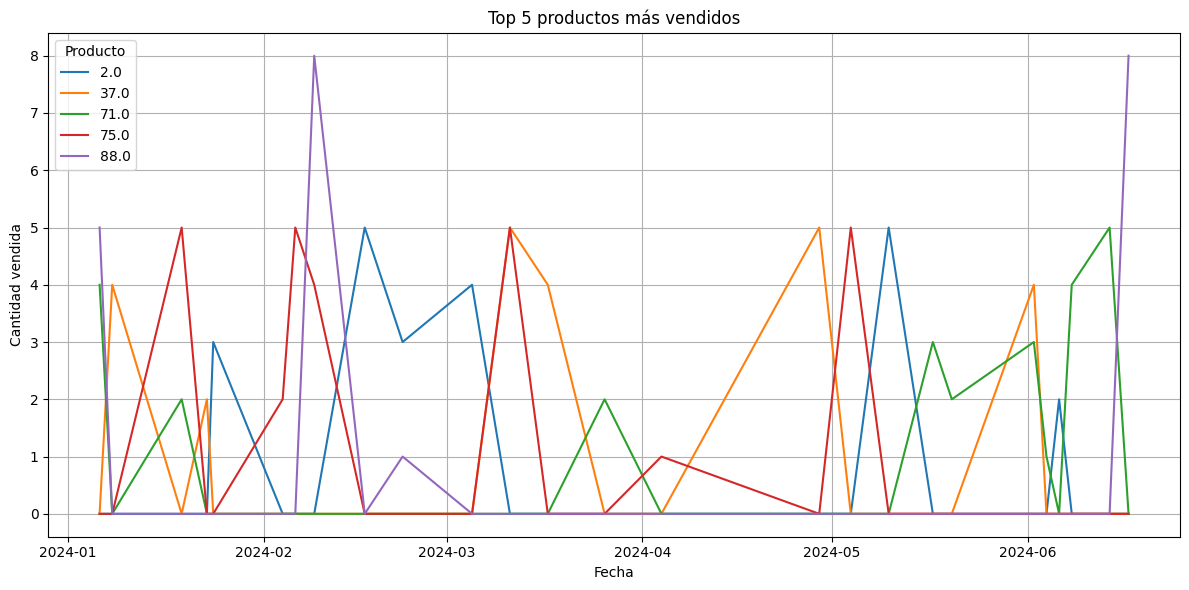

In [284]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Encontrar los 5 productos más vendidos (por cantidad total)
top5 = (
    df_pronostico.groupby("nombre_producto")["cantidad"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

# 2. Filtrar solo esos productos
df_top5 = df_pronostico[df_pronostico["nombre_producto"].isin(top5)]

# 3. Crear tabla pivote para graficar
pivot = df_top5.pivot_table(
    index="fecha",
    columns="nombre_producto",
    values="cantidad",
    aggfunc="sum"
).fillna(0)

# 4. Graficar
plt.figure(figsize=(12,6))
plt.plot(pivot)
plt.title("Top 5 productos más vendidos")
plt.xlabel("Fecha")
plt.ylabel("Cantidad vendida")
plt.legend(pivot.columns, title="Producto")
plt.grid(True)
plt.tight_layout()
plt.show()
